In [1]:
import ee
import os
import geemap
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from features_utils import add_indices, correlation_matrix


In [3]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points.csv"
indices_fp = PROJECT_ROOT / "configs" / "indices.json"

samples = pd.read_csv(sample_fp)

In [4]:
samples = add_indices(samples, indices_file= indices_fp)

In [8]:
samples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  116 non-null    int64  
 1   B11         116 non-null    int64  
 2   B12         116 non-null    int64  
 3   B2          116 non-null    int64  
 4   B3          116 non-null    int64  
 5   B4          116 non-null    int64  
 6   B5          116 non-null    int64  
 7   B6          116 non-null    int64  
 8   B7          116 non-null    int64  
 9   B8          116 non-null    int64  
 10  B8A         116 non-null    int64  
 11  lat         116 non-null    float64
 12  lc          114 non-null    float64
 13  location    116 non-null    object 
 14  lon         116 non-null    float64
 15  obs_date    116 non-null    object 
 16  NDVI        116 non-null    float64
 17  NDWI        116 non-null    float64
 18  MNDWI       116 non-null    float64
 19  GNDVI       116 non-null    f

In [9]:
samples.describe()

,Unnamed: 0,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,NDBI,NDAVI,RR1,EVI,SAVI,DVI,OSAVI,AWEI,SABI,BSI
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,...,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.500000,1372.991379,782.500000,398.672414,663.284483,514.706897,1021.586207,2386.853448,2760.612069,2773.396552,...,-0.258764,0.585106,0.372001,1.858938,0.819145,2110.112069,0.546157,-239.349138,2.382134,-0.211495
std,33.630343,819.877854,606.284486,367.967857,414.802642,526.919745,545.245761,1564.560053,1907.553424,1958.156959,...,0.259379,0.367877,0.249709,2.582250,0.553525,1836.357518,0.369077,2623.524318,2.088860,0.245094
min,0.000000,32.000000,27.000000,114.000000,112.000000,82.000000,89.000000,59.000000,56.000000,81.000000,...,-0.731142,-0.434343,-0.360144,-3.855422,-0.502959,-176.000000,-0.335756,-5190.250000,-0.182796,-0.645841
25%,28.750000,775.500000,378.000000,221.000000,433.500000,222.000000,678.750000,1039.750000,1200.750000,1149.500000,...,-0.490061,0.418822,0.166381,0.376903,0.299103,507.750000,0.199428,-2091.937500,0.343418,-0.435655
50%,57.500000,1439.000000,605.500000,276.500000,589.000000,282.500000,1036.000000,2302.000000,2496.500000,2518.500000,...,-0.308322,0.737799,0.425734,2.199670,1.056218,1859.500000,0.704348,77.375000,2.101163,-0.222346
75%,86.250000,2022.250000,999.000000,432.500000,815.250000,607.500000,1329.500000,3512.500000,4039.250000,4294.750000,...,-0.003184,0.874206,0.589109,2.596246,1.311381,3653.000000,0.874328,1052.875000,4.360941,-0.004517
max,115.000000,3495.000000,2766.000000,2346.000000,2468.000000,2444.000000,2842.000000,5704.000000,7039.000000,7056.000000,...,0.287430,0.936618,0.728947,23.365385,1.407553,6194.000000,0.938419,6792.500000,7.174070,0.292175


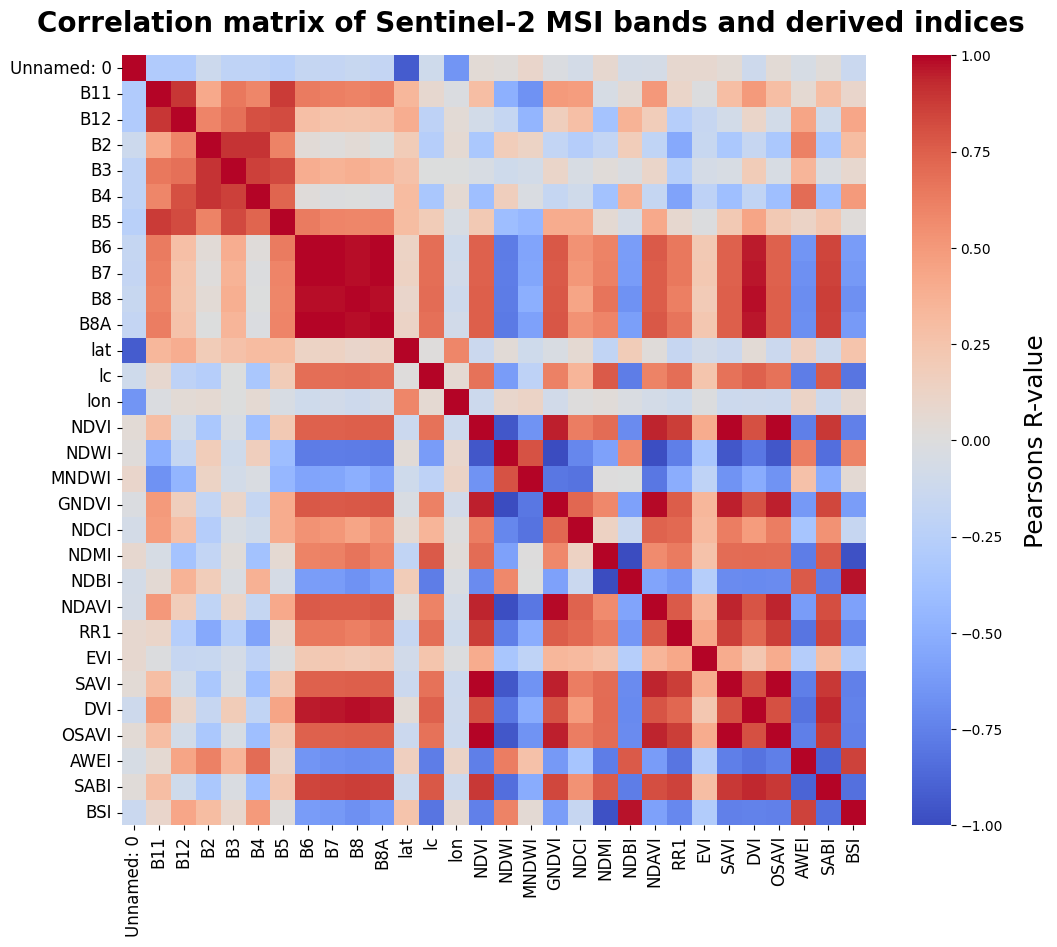

Unnamed: 0   -0.105526
B11           0.073935
B12          -0.216964
B2           -0.258536
B3           -0.000222
B4           -0.332703
B5            0.190664
B6            0.690718
B7            0.688573
B8            0.701575
B8A           0.682427
lat           0.013869
lc            1.000000
lon           0.057206
NDVI          0.679005
NDWI         -0.610004
MNDWI        -0.215710
GNDVI         0.610004
NDCI          0.346855
NDMI          0.766599
NDBI         -0.766599
NDAVI         0.602000
RR1           0.695047
EVI           0.249817
SAVI          0.679133
DVI           0.746380
OSAVI         0.679046
AWEI         -0.767893
SABI          0.776785
BSI          -0.808354
Name: lc, dtype: float64


In [10]:
corr = correlation_matrix(samples)

print(corr["lc"])